# Exercises

There are three exercises in this notebook:

1. Use the cross-validation method to test the linear regression with different $\alpha$ values, at least three.
2. Implement a SGD method that will train the Lasso regression for 10 epochs.
3. Extend the Fisher's classifier to work with two features. Use the class as the $y$.

## 1. Cross-validation linear regression

You need to change the variable ``alpha`` to be a list of alphas. Next do a loop and finally compare the results.

In [46]:
import numpy as np
from sklearn.model_selection import KFold

x = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(-1, 1)
y = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(-1, 1)

I = np.identity(2)
alphas = [0.01, 0.1, 1.0, 10.0]
kf = KFold(n_splits=5)

for alpha in alphas:
    total_error = 0
    for train_index, test_index in kf.split(x):
        x_train, x_test = x[train_index], x[test_index]
        y_train, y_test = y[train_index], y[test_index]

        x_train = np.asmatrix(np.c_[np.ones((len(x_train), 1)), x_train])
        x_test = np.asmatrix(np.c_[np.ones((len(x_test), 1)), x_test])

        w = np.linalg.inv(x_train.T * x_train + alpha * I) * x_train.T * y_train
        y_pred = x_test * w
        total_error += np.mean((np.asarray(y_pred) - y_test) ** 2)

    print(f"alpha={alpha:.2f}, mean MSE={total_error / kf.n_splits:.4f}")


alpha=0.01, mean MSE=460.0895
alpha=0.10, mean MSE=518.7377
alpha=1.00, mean MSE=701.7603
alpha=10.00, mean MSE=750.2355


## 2. Implement based on the Ridge regression example, the Lasso regression.

Please implement the SGD method and compare the results with the sklearn Lasso regression results. 

In [47]:
def sgd(x, y, alpha=0.1, lr=1e-6, epochs=10):
    w = np.zeros(x.shape[1])
    for _ in range(epochs):
        for i in range(len(x)):
            xi = np.asarray(x[i]).ravel()
            yi = np.asarray(y[i]).ravel()[0]
            pred = np.dot(xi, w)
            grad = -2 * xi * (yi - pred) + alpha * np.sign(w)
            w -= lr * grad
    return w


In [48]:
from sklearn.linear_model import Lasso

x = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(-1, 1)
y = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(-1, 1)

x_mat = np.asmatrix(np.c_[np.ones((15, 1)), x])
alpha = 0.1

w_sgd = sgd(x_mat, y, alpha=alpha)
print("SGD weights:", w_sgd)

lasso_model = Lasso(alpha=alpha)
lasso_model.fit(x, y.ravel())
print("Lasso intercept:", lasso_model.intercept_, "coef:", lasso_model.coef_)


SGD weights: [0.00283717 0.59172102]
Lasso intercept: -180.85790859980537 coef: [1.61776499]


## 3. Extend the Fisher's classifier

Write numpy code that performs Fisher classification using all the features of Iris data. Choose species nr 1 and 2 as two classes. Plot original data and their projection. Using obtained model classify the flower with the folowing features: [6.45, 2.85, 4.25, 1.25].

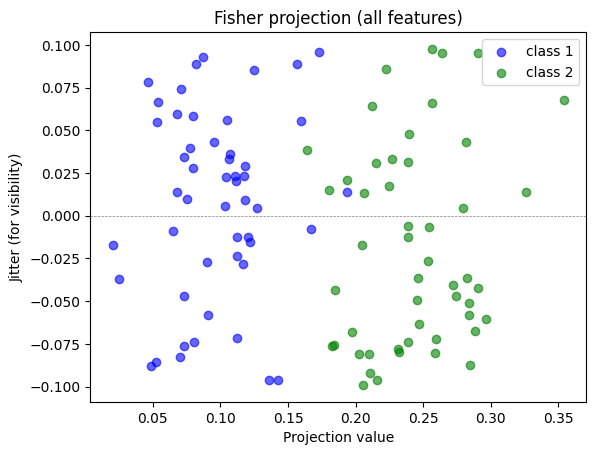

Projection: 0.0640, threshold: 0.1700, predicted class: 1


In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn import preprocessing

iris_data, iris_labels = load_iris(return_X_y=True)

x1 = iris_data[np.where(iris_labels == 1)]
x2 = iris_data[np.where(iris_labels == 2)]

mean_x1 = np.mean(x1, axis=0)
mean_x2 = np.mean(x2, axis=0)

Sw = np.dot((x1 - mean_x1).T, (x1 - mean_x1)) + np.dot((x2 - mean_x2).T, (x2 - mean_x2))
w = np.dot(np.linalg.inv(Sw), (mean_x2 - mean_x1))

proj_x1 = np.dot(x1, w)
proj_x2 = np.dot(x2, w)

np.random.seed(0)
jitter1 = np.random.uniform(-0.1, 0.1, x1.shape[0])
jitter2 = np.random.uniform(-0.1, 0.1, x2.shape[0])

plt.scatter(proj_x1, jitter1, c="blue", label="class 1", alpha=0.6)
plt.scatter(proj_x2, jitter2, c="green", label="class 2", alpha=0.6)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.5)
plt.legend()
plt.title("Fisher projection (all features)")
plt.xlabel("Projection value")
plt.ylabel("Jitter (for visibility)")
plt.show()

new_flower = np.array([6.45, 2.85, 4.25, 1.25]).reshape(1, -1)
proj = np.dot(new_flower, w)[0]

threshold = (np.dot(mean_x1, w) + np.dot(mean_x2, w)) / 2
predicted_class = 2 if proj > threshold else 1
print(f"Projection: {proj:.4f}, threshold: {threshold:.4f}, predicted class: {predicted_class}")
